In [ ]:
import numpy as np
import torch
from torch.utils.data import Subset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler


In [ ]:
import random

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)

# Ensure GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)



# CIFAR-10 class names
class_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Transforms
image_transforms_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
image_transforms_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 3. Download CIFAR-10
train_data = datasets.CIFAR10(root='./dataset_cache', train=True, download=True, transform=image_transforms_train)
test_data = datasets.CIFAR10(root='./dataset_cache', train=False, download=True, transform=image_transforms_test)

# Extract the class labels as a numpy array
targets = np.array(train_data.targets)


Using device: cuda


100%|██████████| 170M/170M [00:05<00:00, 29.9MB/s]


In [ ]:
# Long-tailed (L-imbalance)
def create_long_tail_indices(y, num_classes=10, max_samples=5000, decay=0.7):
    indices = []
    for c in range(num_classes):
        class_indices = np.where(y == c)[0]
        num_samples = int(max_samples * (decay ** c))
        sampled = np.random.choice(class_indices, num_samples, replace=False)
        indices.extend(sampled)
    np.random.shuffle(indices)
    return indices



In [ ]:
# Step-shaped (SS-imbalance)
def create_step_shape_indices(y, head_classes=5, head_samples=5000, tail_samples=500):
    indices = []
    for c in range(10):
        class_indices = np.where(y == c)[0]
        num_samples = head_samples if c < head_classes else tail_samples
        sampled = np.random.choice(class_indices, num_samples, replace=False)
        indices.extend(sampled)
    np.random.shuffle(indices)
    return indices

In [ ]:
# Almost-single-class (AS-imbalance)



import numpy as np

def create_almost_single_class_indices(y, majority_class=0, majority_samples=5000, other_samples=500):
    """
    Create indices for AS-imbalance (Almost Single-class) in a dataset.

    Args:
        y (array-like): Array of all labels (e.g. np.array(train_data.targets))
        majority_class (int): The class label to be majority.
        majority_samples (int): Number of samples for majority class.
        other_samples (int): Number of samples for all other classes.

    Returns:
        indices (list): List of selected indices to create the imbalanced subset.
    """
    indices = []
    for c in np.unique(y):
        class_indices = np.where(y == c)[0]
        n_samples = majority_samples if c == majority_class else other_samples
        sampled = np.random.choice(class_indices, n_samples, replace=False)
        indices.extend(sampled)
    np.random.shuffle(indices)
    return indices


Step 3: Create Subsets for Each Imbalance Pattern
python
Copy
Edit


In [ ]:
# Get indices for each type
l_indices = create_long_tail_indices(targets, num_classes=10, max_samples=5000, decay=0.7)
ss_indices = create_step_shape_indices(targets, head_classes=5, head_samples=5000, tail_samples=500)
as_indices = create_almost_single_class_indices(targets, majority_class=0, majority_samples=5000, other_samples=500)

# Create subset datasets
train_data_Limb = Subset(train_data, l_indices)
train_data_SSimb = Subset(train_data, ss_indices)
train_data_ASimb = Subset(train_data, as_indices)


In [ ]:
batch_size = 128
val_fraction = 0.1  # 10% for validation

def split_and_create_loaders(dataset):
    total_len = len(dataset)
    val_len = int(val_fraction * total_len)
    train_len = total_len - val_len
    generator = torch.Generator().manual_seed(0)
    train_set, val_set = random_split(dataset, [train_len, val_len], generator=generator)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

# For each pattern
train_loader_Limb, val_loader_Limb = split_and_create_loaders(train_data_Limb)
train_loader_SSimb, val_loader_SSimb = split_and_create_loaders(train_data_SSimb)
train_loader_ASimb, val_loader_ASimb = split_and_create_loaders(train_data_ASimb)

# Test loader stays the same for all
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


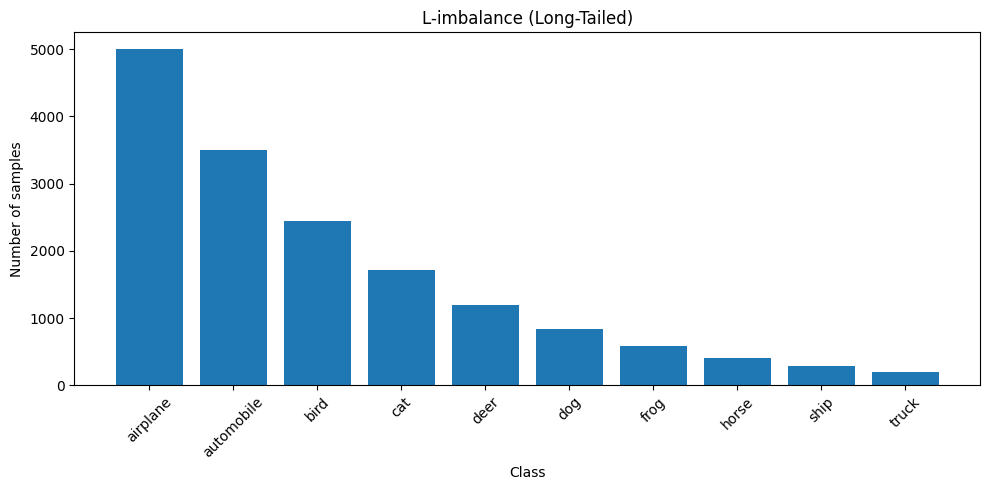

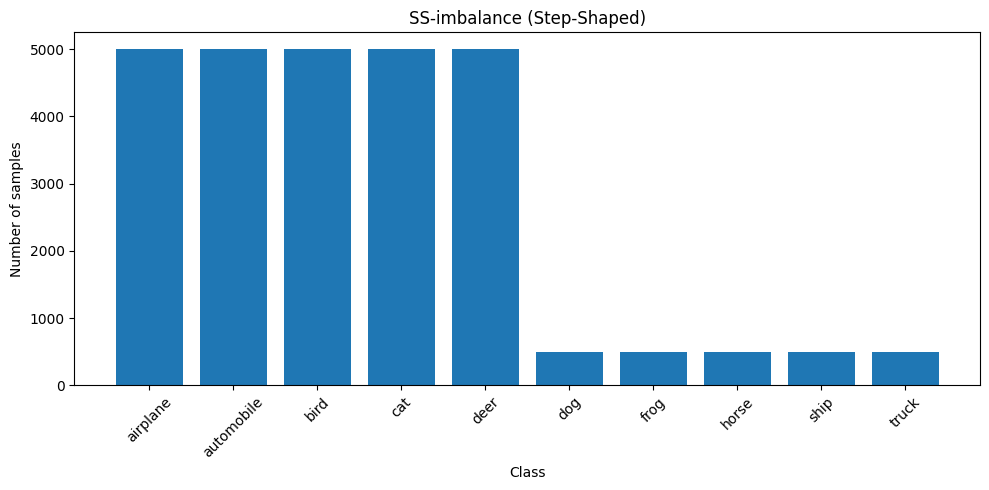

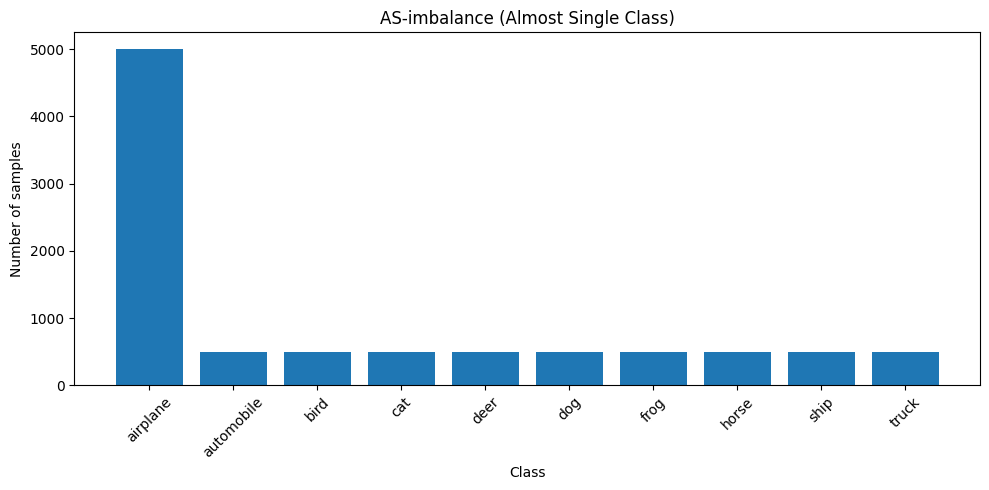

In [ ]:
import matplotlib.pyplot as plt

def plot_class_dist(dataset, class_labels, title):
    labels = []
    for i in range(len(dataset)):
        _, label = dataset[i]
        labels.append(label)
    class_counts = np.bincount(labels, minlength=len(class_labels))
    plt.figure(figsize=(10, 5))
    plt.bar(class_labels, class_counts)
    plt.xlabel('Class')
    plt.ylabel('Number of samples')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



# Now call your function for each dataset
plot_class_dist(train_data_Limb, class_labels, 'L-imbalance (Long-Tailed)')
plot_class_dist(train_data_SSimb, class_labels, 'SS-imbalance (Step-Shaped)')
plot_class_dist(train_data_ASimb, class_labels, 'AS-imbalance (Almost Single Class)')


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

def train_and_evaluate(
    train_loader,
    val_loader,
    test_loader,
    class_names,
    num_epochs=10,
    device='cuda' if torch.cuda.is_available() else 'cpu'
):
    # 1. Re-initialize model
    model = torchvision.models.densenet121(weights=None)
    model.features.conv0 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.features.pool0 = nn.Identity()
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Linear(num_ftrs, 10)
    model = model.to(device)

    # 2. Re-initialize optimizer and loss
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    # 3. Training loop
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}")

        # Validation phase (optional)
        if val_loader is not None:
            model.eval()
            val_loss, val_correct, val_total = 0.0, 0, 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item() * images.size(0)
                    _, preds = torch.max(outputs, 1)
                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)
            val_loss = val_loss / val_total
            val_acc = val_correct / val_total
            val_losses.append(val_loss)
            val_accuracies.append(val_acc)
            print(f"Validation Loss: {val_loss:.4f}, Validation Acc: {val_acc:.4f}")

    # Plot training/validation curves
    epochs = range(1, num_epochs+1)
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, label='Train Loss')
    if val_losses:
        plt.plot(epochs, val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss per Epoch')

    plt.subplot(1,2,2)
    plt.plot(epochs, train_accuracies, label='Train Acc')
    if val_accuracies:
        plt.plot(epochs, val_accuracies, label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy per Epoch')
    plt.show()

    # Test evaluation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(classification_report(all_labels, all_preds, target_names=class_names))
    return model  # Optionally return for further analysis


=== L-imbalance Experiment ===
Epoch [1/10] - Train Loss: 1.3165, Train Acc: 0.5438
Validation Loss: 1.1168, Validation Acc: 0.5991
Epoch [2/10] - Train Loss: 1.0766, Train Acc: 0.6216
Validation Loss: 0.9732, Validation Acc: 0.6794
Epoch [3/10] - Train Loss: 0.9324, Train Acc: 0.6740
Validation Loss: 0.9486, Validation Acc: 0.6646
Epoch [4/10] - Train Loss: 0.8129, Train Acc: 0.7158
Validation Loss: 0.8408, Validation Acc: 0.7165
Epoch [5/10] - Train Loss: 0.7212, Train Acc: 0.7466
Validation Loss: 0.7646, Validation Acc: 0.7406
Epoch [6/10] - Train Loss: 0.6366, Train Acc: 0.7775
Validation Loss: 0.6744, Validation Acc: 0.7573
Epoch [7/10] - Train Loss: 0.5696, Train Acc: 0.8003
Validation Loss: 0.6653, Validation Acc: 0.7801
Epoch [8/10] - Train Loss: 0.5247, Train Acc: 0.8225
Validation Loss: 0.6328, Validation Acc: 0.7974
Epoch [9/10] - Train Loss: 0.4785, Train Acc: 0.8333
Validation Loss: 0.5900, Validation Acc: 0.8091
Epoch [10/10] - Train Loss: 0.4382, Train Acc: 0.8498
Valida

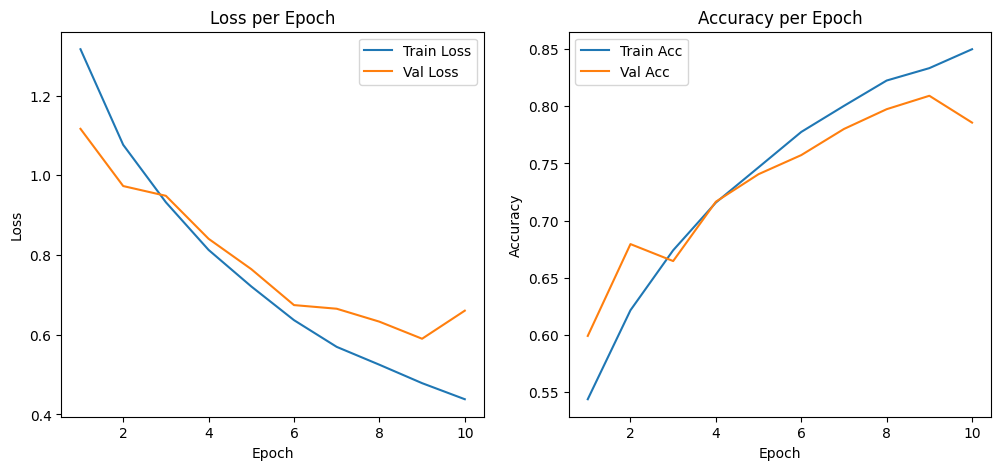

              precision    recall  f1-score   support

    airplane       0.69      0.83      0.75      1000
  automobile       0.54      0.98      0.70      1000
        bird       0.64      0.70      0.67      1000
         cat       0.76      0.41      0.53      1000
        deer       0.51      0.87      0.64      1000
         dog       0.61      0.70      0.65      1000
        frog       0.84      0.75      0.79      1000
       horse       0.83      0.42      0.55      1000
        ship       0.91      0.59      0.72      1000
       truck       0.95      0.43      0.59      1000

    accuracy                           0.67     10000
   macro avg       0.73      0.67      0.66     10000
weighted avg       0.73      0.67      0.66     10000

=== SS-imbalance Experiment ===
Epoch [1/10] - Train Loss: 1.3012, Train Acc: 0.5328
Validation Loss: 1.1904, Validation Acc: 0.5844
Epoch [2/10] - Train Loss: 0.9997, Train Acc: 0.6523
Validation Loss: 1.0692, Validation Acc: 0.6476
Epoch [

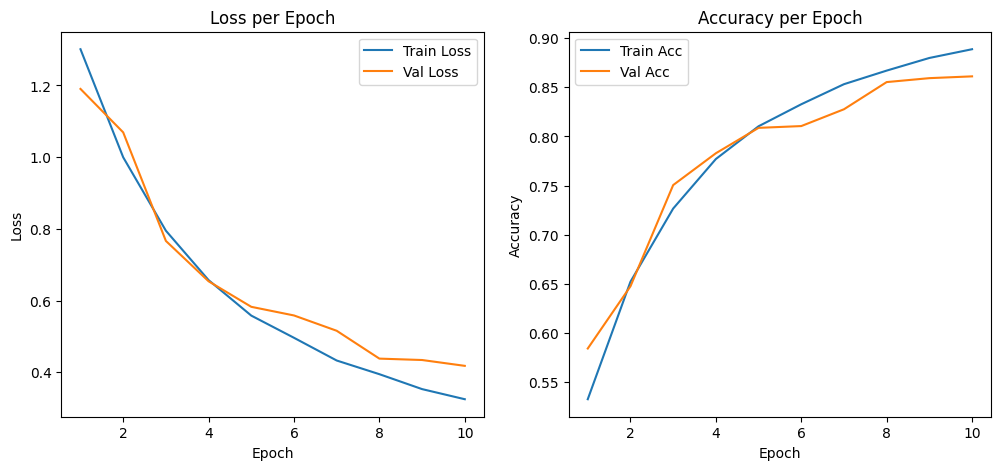

              precision    recall  f1-score   support

    airplane       0.51      0.95      0.66      1000
  automobile       0.76      0.96      0.85      1000
        bird       0.58      0.85      0.69      1000
         cat       0.45      0.82      0.58      1000
        deer       0.64      0.90      0.75      1000
         dog       0.96      0.21      0.35      1000
        frog       0.98      0.46      0.63      1000
       horse       0.96      0.48      0.64      1000
        ship       0.95      0.38      0.55      1000
       truck       0.98      0.55      0.70      1000

    accuracy                           0.66     10000
   macro avg       0.78      0.66      0.64     10000
weighted avg       0.78      0.66      0.64     10000

=== AS-imbalance Experiment ===
Epoch [1/10] - Train Loss: 1.3876, Train Acc: 0.5482
Validation Loss: 1.4742, Validation Acc: 0.5137
Epoch [2/10] - Train Loss: 1.1464, Train Acc: 0.6104
Validation Loss: 1.2258, Validation Acc: 0.5926
Epoch [

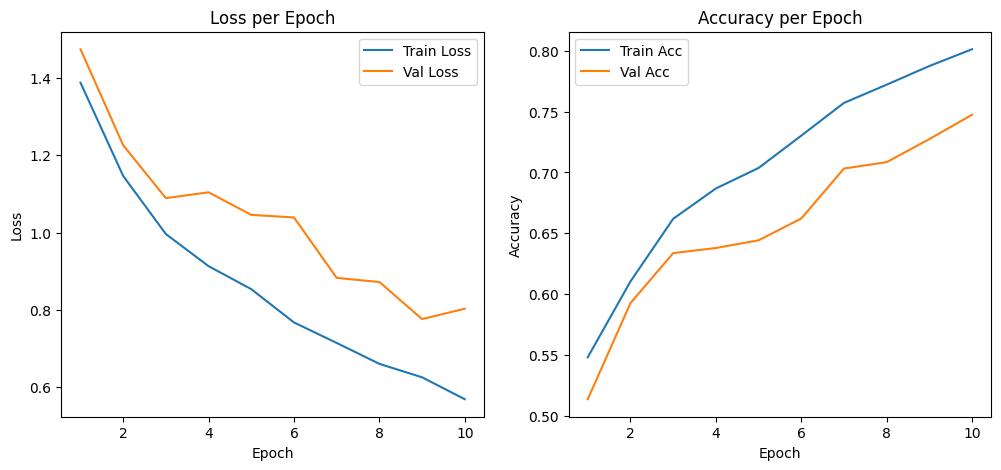

              precision    recall  f1-score   support

    airplane       0.32      0.97      0.48      1000
  automobile       0.91      0.63      0.74      1000
        bird       0.35      0.54      0.42      1000
         cat       0.52      0.31      0.39      1000
        deer       0.66      0.41      0.51      1000
         dog       0.67      0.35      0.46      1000
        frog       0.61      0.72      0.66      1000
       horse       0.78      0.55      0.64      1000
        ship       0.89      0.41      0.56      1000
       truck       0.91      0.58      0.71      1000

    accuracy                           0.55     10000
   macro avg       0.66      0.55      0.56     10000
weighted avg       0.66      0.55      0.56     10000



DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): Identity()
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(96, 128, kernel_s

In [ ]:
# Assume you have already split your loaders:
# train_loader_Limb, val_loader_Limb, etc.
# test_loader and class_names are already defined.

print("=== L-imbalance Experiment ===")
train_and_evaluate(train_loader_Limb, val_loader_Limb, test_loader, class_labels, num_epochs=10)

print("=== SS-imbalance Experiment ===")
train_and_evaluate(train_loader_SSimb, val_loader_SSimb, test_loader, class_labels, num_epochs=10)

print("=== AS-imbalance Experiment ===")
train_and_evaluate(train_loader_ASimb, val_loader_ASimb, test_loader, class_labels, num_epochs=10)


#